In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT = "/content/drive/MyDrive/american_express"
os.chdir(PROJECT)

print(os.getcwd())

/content/drive/MyDrive/american_express


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/american_express/datasets/Round1_Dataset.csv")
print("shape:", df.shape)
print("="*80)
print("\n", df.head())

shape: (500000, 24)

    id           f1  f2  f3        f4            f5          f6           f7  \
0   0     0.000000   0   1  98615.44   5620.938246         NaN          NaN   
1   1     0.000000   0   0  21241.06  10196.878460  13865.4026    425.04840   
2   2  1224.690475   0   1       NaN     16.160000         NaN          NaN   
3   3     0.000000   1   0       NaN   1635.316863   3231.1968   -269.15308   
4   4  3824.366700   0   0   7140.87   5007.271790   4064.2152  16079.35060   

         f8       f9  ...    f14   f15        f16      f17      f18  f19  f20  \
0       NaN      NaN  ...    0.0   0.0  49.280210   1960.0   1900.0  2.0  1.0   
1   27.9986    0.000  ...  196.0   5.0  63.759364  34300.0  34650.0  3.0  2.0   
2       NaN      NaN  ...    0.0   0.0  19.646836      NaN      NaN  1.0  1.0   
3    0.0000    0.000  ...    0.0   0.0   9.143074  12348.0  12474.0  2.0  1.0   
4  377.9055  556.974  ...    0.0  11.0  63.759364   3672.0   3528.0  3.0  1.0   

        f21  f22

In [6]:
features = pd.read_csv("/content/drive/MyDrive/american_express/datasets/feature_description.csv")
print("shape:", features.shape)
print("="*80)
print("\n", features)

shape: (24, 2)

    Feature Name                   Feature Description
0            id                                    id
1            f1   Average Revolve Balance in last 12m
2            f2        Cancellation Calls in last 12m
3            f3  Cancellation Calls due to Collection
4            f4                Rewards Points Balance
5            f5               Total Spend in last 12m
6            f6                 Airlines Spend in 12m
7            f7                    Other Spend in 12m
8            f8            Entertainment Spend in 12m
9            f9                  Lodging Spend in 12m
10          f10                   Dining Spend in 12m
11          f11             Average Risk Score in 12m
12          f12               Login Counts to website
13          f13                   Lounge Access Count
14          f14              Credits used in airlines
15          f15                    Cab benefits usage
16          f16      Entertainment Credit Used Amount
17         

In [7]:
feature_map = {}

for _, row in features.iterrows():
    old_name = row['Feature Name']
    new_name = (
        row['Feature Description']
        .lower()
        .replace(" in last ", "_")
        .replace(" in ", "_")
        .replace(" ", "_")
    )
    feature_map[old_name] = new_name

df.rename(columns=feature_map, inplace=True)

In [8]:
df.head()

,id,average_revolve_balance_12m,cancellation_calls_12m,cancellation_calls_due_to_collection,rewards_points_balance,total_spend_12m,airlines_spend_12m,other_spend_12m,entertainment_spend_12m,lodging_spend_12m,...,credits_used_airlines,cab_benefits_usage,entertainment_credit_used_amount,total_lend_line_amount,total_consumer_lend_line_amount,number_of_supplementary_accounts,count_of_active_charge_cards,rewards_point_redeemed_12months,emails_open_6_months,emails_clicked_6_months
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1.0,1.0,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2.0,1.0,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.0,0.0,NaN


In [9]:
df.rename(columns={'cancellation_calls_due_to_collectioon': 'collection_cancellation_calls', 'login_counts_to_website':'website_login_counts', 'number_of_supplementary_accounts':'supplementary_account_count', 'count_of_active_charge_cards':'active_charge_card_count'}, inplace=True)

In [10]:
df.head()

,id,average_revolve_balance_12m,cancellation_calls_12m,cancellation_calls_due_to_collection,rewards_points_balance,total_spend_12m,airlines_spend_12m,other_spend_12m,entertainment_spend_12m,lodging_spend_12m,...,credits_used_airlines,cab_benefits_usage,entertainment_credit_used_amount,total_lend_line_amount,total_consumer_lend_line_amount,supplementary_account_count,active_charge_card_count,rewards_point_redeemed_12months,emails_open_6_months,emails_clicked_6_months
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1.0,1.0,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2.0,1.0,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.0,0.0,NaN


In [11]:
print(df.columns)

Index(['id', 'average_revolve_balance_12m', 'cancellation_calls_12m',
       'cancellation_calls_due_to_collection', 'rewards_points_balance',
       'total_spend_12m', 'airlines_spend_12m', 'other_spend_12m',
       'entertainment_spend_12m', 'lodging_spend_12m', 'dining_spend_12m',
       'average_risk_score_12m', 'website_login_counts', 'lounge_access_count',
       'credits_used_airlines', 'cab_benefits_usage',
       'entertainment_credit_used_amount', 'total_lend_line_amount',
       'total_consumer_lend_line_amount', 'supplementary_account_count',
       'active_charge_card_count', 'rewards_point_redeemed_12months',
       'emails_open_6_months', 'emails_clicked_6_months'],
      dtype='object')


In [12]:
df.isnull().sum()

,0
id,0
average_revolve_balance_12m,0
cancellation_calls_12m,0
cancellation_calls_due_to_collection,0
rewards_points_balance,257228
total_spend_12m,6340
airlines_spend_12m,115698
other_spend_12m,115698
entertainment_spend_12m,115698
lodging_spend_12m,115698


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,500000.0,249999.500000,144337.711634,0.000000,124999.750000,249999.500000,374999.250000,499999.000000
average_revolve_balance_12m,500000.0,2467.312088,4801.261745,0.000000,0.000000,0.000000,2436.194862,17967.726330
cancellation_calls_12m,500000.0,0.173948,0.379065,0.000000,0.000000,0.000000,0.000000,1.000000
cancellation_calls_due_to_collection,500000.0,0.108608,0.311147,0.000000,0.000000,0.000000,0.000000,1.000000
rewards_points_balance,242772.0,126607.131109,183366.588497,2.000000,8097.067500,50705.190000,150490.920000,697899.350000
total_spend_12m,493660.0,3464.813312,3710.776424,0.000000,668.571423,2165.850798,4911.806492,13596.279900
airlines_spend_12m,384302.0,10032.050115,13981.489112,0.000000,636.826300,4022.766000,12870.158300,52198.432000
other_spend_12m,384302.0,30821.546800,39491.042972,-274.646000,3337.599825,14396.270950,41278.605275,146700.554000
entertainment_spend_12m,384302.0,1522.992929,2521.700018,0.000000,0.000000,303.993300,1777.084625,9419.874000
lodging_spend_12m,384302.0,1651.736560,2869.234123,0.000000,0.000000,264.746000,1809.549225,10828.994000


In [14]:

category_map = {
    'average_revolve_balance_12m':       'Revenue Driver',
    'total_spend_12m':                   'Revenue Driver',
    'airlines_spend_12m':                'Revenue Driver',
    'other_spend_12m':                   'Revenue Driver',
    'entertainment_spend_12m':           'Revenue Driver',
    'lodging_spend_12m':                 'Revenue Driver',
    'dining_spend_12m':                  'Revenue Driver',

    'cancellation_calls_12m':            'Risk Driver',
    'collection_cancellation_calls':     'Risk Driver',
    'average_risk_score_12m':            'Risk Driver',

    'lounge_access_count':               'Benefit Usage / Direct Cost',
    'credits_used_airlines':             'Benefit Usage / Direct Cost',
    'cab_benefits_usage':                'Benefit Usage / Direct Cost',
    'entertainment_credit_used_amount':  'Benefit Usage / Direct Cost',
    'rewards_point_redeemed_12months':   'Benefit Usage / Direct Cost',

    'rewards_points_balance':            'Future Liability',

    'website_login_counts':              'Behaviour & Engagement',
    'supplementary_account_count':       'Behaviour & Engagement',
    'active_charge_card_count':          'Behaviour & Engagement',
    'emails_open_6_months':              'Behaviour & Engagement',
    'emails_clicked_6_months':           'Behaviour & Engagement',

    'total_lend_line_amount':            'Credit Relationship',
    'total_consumer_lend_line_amount':   'Credit Relationship',
}

orig_map = dict(zip(features['Feature Name'],
                     [c for c in df.columns if False] or features['Feature Description']))
code_to_business = {}
for _, row in features.iterrows():
    fname = row['Feature Name']
    # find the business name this original code maps to by description transform already applied
    pass

cat_df = pd.DataFrame({
    'business_column': list(category_map.keys()),
    'business_category': list(category_map.values()),
}).sort_values('business_category').reset_index(drop=True)

print(cat_df.to_string(index=False))
print("\nCategory sizes:")
print(cat_df['business_category'].value_counts())


                 business_column           business_category
         emails_clicked_6_months      Behaviour & Engagement
            emails_open_6_months      Behaviour & Engagement
        active_charge_card_count      Behaviour & Engagement
     supplementary_account_count      Behaviour & Engagement
            website_login_counts      Behaviour & Engagement
           credits_used_airlines Benefit Usage / Direct Cost
 rewards_point_redeemed_12months Benefit Usage / Direct Cost
entertainment_credit_used_amount Benefit Usage / Direct Cost
              cab_benefits_usage Benefit Usage / Direct Cost
             lounge_access_count Benefit Usage / Direct Cost
          total_lend_line_amount         Credit Relationship
 total_consumer_lend_line_amount         Credit Relationship
          rewards_points_balance            Future Liability
                dining_spend_12m              Revenue Driver
               lodging_spend_12m              Revenue Driver
         entertainment_s

## 3. Hypothesis Register

Hypotheses formed **before** touching distributions, to be validated or rejected by evidence below.
Each is tagged with the section that resolves it.

| # | Hypothesis | Rationale (why we'd expect this) | Resolved in |
|---|---|---|---|
| H1 | Missingness is not random — it clusters by business sub-system (spend breakdown, rewards, lend line, benefits, email) | Data was very likely assembled by joining several internal source systems (spend engine, loyalty engine, credit-line engine, servicing/CRM, marketing) that don't all cover every cardmember | §5 Missing Value Investigation |
| H2 | `average_risk_score_12m` correlates positively with collections/cancellation activity | Risk scores are built to predict exactly this kind of behavior | §7 Multivariate Relationships |
| H3 | Riskier cardmembers are assigned lower lend lines | Standard issuer risk practice — this is a charge card, but American Express still manages exposure | §7 Multivariate Relationships |
| H4 | Category-level spend columns (airline/dining/lodging/entertainment/other) are highly inter-correlated — high spenders spend everywhere, not in one category | Premier's benefit structure rewards broad usage, and general affluence drives multi-category spend | §7 Multivariate Relationships |
| H5 | Benefit-usage features (lounge, credits, cab, entertainment) will show a "heavy-tail, many-zeros" distribution — most cardmembers under-use the very benefits that justify the annual fee | Well-documented industry pattern: premium travel benefits are usually used by a minority of cardholders | §6 Univariate Distributions |
| H6 | Engagement features (logins, email opens/clicks) are only weakly related to spend, but may matter for retention/cost, not directly for revenue | Engagement is a behavioral, not a transactional, signal | §7 Multivariate Relationships |
| H7 | There exist distinguishable cardmember personas (e.g., "big travel spender / benefit non-user" vs. "revolver" vs. "engaged loyalist" vs. "low-engagement baseline") | The product bundles very different value propositions (travel, lifestyle, credit) that different customers will lean into differently | §9 Customer Personas |
| H8 | At least one feature contains a data-quality anomaly (negative values, systematic missingness pattern, or repeated placeholder-like values) that needs an explicit decision, not silent imputation | 500K-row real-world extracts virtually always contain at least one such issue | §8 Anomaly Investigation |


In [15]:

miss = df.isnull().sum().sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
miss_tbl = pd.concat([miss, miss_pct], axis=1, keys=['missing_count', 'missing_pct'])
miss_tbl = miss_tbl[miss_tbl['missing_count'] > 0]
print(miss_tbl.to_string())


                                  missing_count  missing_pct
emails_clicked_6_months                  438965        87.79
total_consumer_lend_line_amount          309444        61.89
total_lend_line_amount                   292254        58.45
rewards_points_balance                   257228        51.45
rewards_point_redeemed_12months          257228        51.45
airlines_spend_12m                       115698        23.14
other_spend_12m                          115698        23.14
entertainment_spend_12m                  115698        23.14
dining_spend_12m                         115698        23.14
lodging_spend_12m                        115698        23.14
emails_open_6_months                      94654        18.93
website_login_counts                      25005         5.00
entertainment_credit_used_amount          13716         2.74
cab_benefits_usage                        13716         2.74
lounge_access_count                       13716         2.74
credits_used_airlines   

In [16]:

# --- Cluster 1: category-level spend breakdown ---
spend_cols = ['airlines_spend_12m', 'other_spend_12m', 'entertainment_spend_12m',
              'lodging_spend_12m', 'dining_spend_12m']
comiss = df[spend_cols].isnull().sum(axis=1)
print("Spend-breakdown cluster — rows by # of these 5 columns missing simultaneously:")
print(comiss.value_counts().sort_index())
print("-> all-5-missing-together count:", (comiss == 5).sum(),
      f"({(comiss==5).mean()*100:.2f}% of dataset)")

# --- Cluster 2: rewards program ---
r_both = ((df['rewards_points_balance'].isnull()) & (df['rewards_point_redeemed_12months'].isnull())).sum()
print("\nRewards cluster — balance & redeemed missing together:", r_both,
      "/ balance missing total:", df['rewards_points_balance'].isnull().sum(),
      "/ redeemed missing total:", df['rewards_point_redeemed_12months'].isnull().sum())
print("Min non-missing rewards_points_balance:", df['rewards_points_balance'].min(),
      "(no zero values observed among non-missing rows:",
      (df['rewards_points_balance'] == 0).sum(), "zeros )")

# --- Cluster 3: lend line ---
l_both = ((df['total_lend_line_amount'].isnull()) & (df['total_consumer_lend_line_amount'].isnull())).sum()
print("\nLend-line cluster — both missing together:", l_both)
print("Min non-missing total_lend_line_amount:", df['total_lend_line_amount'].min(),
      "(no zero lend lines observed:", (df['total_lend_line_amount'] == 0).sum(), "zeros )")

# --- Cluster 4: benefit usage ---
ben_cols = ['lounge_access_count', 'credits_used_airlines', 'cab_benefits_usage',
            'entertainment_credit_used_amount']
comiss_b = df[ben_cols].isnull().sum(axis=1)
print("\nBenefit-usage cluster — rows by # of these 4 columns missing simultaneously:")
print(comiss_b.value_counts().sort_index())

# --- Cluster 5: email engagement ---
opens = df['emails_open_6_months']
clicks = df['emails_clicked_6_months']
print("\nEmail cluster:")
print("  clicks missing where opens missing:", clicks[opens.isnull()].isnull().sum(), "/", opens.isnull().sum())
print("  clicks missing where opens == 0   :", clicks[opens == 0].isnull().sum(), "/", (opens == 0).sum())
print("  clicks present where opens > 0    :", clicks[opens > 0].notnull().sum(), "/", (opens > 0).sum())


Spend-breakdown cluster — rows by # of these 5 columns missing simultaneously:
0    384302
5    115698
Name: count, dtype: int64
-> all-5-missing-together count: 115698 (23.14% of dataset)

Rewards cluster — balance & redeemed missing together: 257228 / balance missing total: 257228 / redeemed missing total: 257228
Min non-missing rewards_points_balance: 2.0 (no zero values observed among non-missing rows: 0 zeros )

Lend-line cluster — both missing together: 292254
Min non-missing total_lend_line_amount: 1000.0 (no zero lend lines observed: 0 zeros )

Benefit-usage cluster — rows by # of these 4 columns missing simultaneously:
0    486284
4     13716
Name: count, dtype: int64

Email cluster:
  clicks missing where opens missing: 94654 / 94654
  clicks missing where opens == 0   : 51966 / 51966
  clicks present where opens > 0    : 61035 / 353380


**Interpretation — H1 CONFIRMED, with 3 distinct mechanisms found:**

1. **Perfectly structural (MCAR-by-design), two clusters:**
   - The 5 spend-category columns are missing **together, in exactly the same 115,698 rows
     (23.14%)**, with zero partial-missing rows. This is not random data loss — it is a clean
     all-or-nothing split, consistent with these ~116K cardmembers being served by a different
     spend-categorization pipeline (or a pipeline that only ever produced the aggregate
     `total_spend_12m`, never the category breakdown).
   - The 4 benefit-usage columns (`lounge_access_count`, `credits_used_airlines`,
     `cab_benefits_usage`, `entertainment_credit_used_amount`) are missing together in exactly
     13,716 rows (2.74%) — same all-or-nothing pattern, smaller scale, most likely a distinct
     benefits-servicing extract that simply doesn't cover every account.

2. **Structural and business-meaningful, not random:**
   - `rewards_points_balance` and `rewards_point_redeemed_12months` are missing in **exactly the
     same 257,228 rows**, and — critically — **no non-missing row has a balance of exactly 0**.
     If "missing" meant "zero rewards," we would expect to see actual zeros in the data; we see
     none. The far more likely explanation is that roughly half the base is **not on a
     points-earning track at all** for this extract (e.g., a different Membership Rewards
     enrollment status), and the field is genuinely inapplicable, not merely "empty."
   - `total_lend_line_amount` / `total_consumer_lend_line_amount` are missing together in 292,254
     rows (58–62%), and again **no non-missing row has a lend line of 0** (minimum observed is
     1,000). Combined with the product fact that Premier is a **charge card with no preset
     spending limit**, the most defensible reading is: **cardmembers without an assigned lend
     line are charge-card-only members who were never underwritten a traditional credit line** —
     this is a legitimate state, not a data error.

3. **Partially structural, partially unexplained (needs a flag, not a confident fill):**
   - `emails_clicked_6_months` is missing in 87.79% of rows. Every row where `emails_open` is
     missing or exactly 0 also has clicks missing (146,620 rows) — logically airtight, since you
     cannot click an email you never opened or that wasn't tracked. But **292,345 additional
     rows have clicks missing even though opens > 0** — for these, we cannot logically infer
     "0 clicks"; we only know the click field wasn't populated. We treat this remainder as a
     genuine data gap, not a confirmed zero.

None of these five clusters should be silently mean/median-imputed — doing so would fabricate
spend mix, rewards liability, or credit exposure that we have positive evidence does not exist
for these cardmembers, or that we cannot confidently set to zero.

### Missing-value handling strategy — decision matrix

| Column(s) | Missingness mechanism | Options considered | Chosen strategy | Why |
|---|---|---|---|---|
| Spend-category cluster (5 cols) | Structural, all-or-nothing (23.14%) | (a) drop rows (b) impute 0 (c) impute mean (d) keep NaN + flag | **(d)** keep NaN, add `has_spend_breakdown` flag | `total_spend_12m` is still present for these rows — the aggregate is real, only the split is missing. Imputing 0 would understate every category; imputing mean would fabricate a spend mix. The flag preserves the information that this cardmember came from a different source system. |
| Benefit-usage cluster (4 cols) | Structural, all-or-nothing (2.74%) | same as above | **impute 0 + flag** `has_benefit_data` | Small share of the base (2.74%); no aggregate proxy exists for these like `total_spend` does for spend. Given the small share, imputing 0 (i.e., "no recorded benefit usage") has minimal distributional impact — validated below. |
| `rewards_points_balance`, `rewards_point_redeemed_12months` | Structural / not-applicable (51.45%) | (a) impute 0 (b) impute median (c) keep NaN + flag | **(c)** keep NaN, add `has_rewards_activity` flag | No zero values exist in the observed data, so 0 is not a defensible fill; these members are very likely not on the same rewards-tracking basis. The flag itself is a legitimate candidate feature (see §10). |
| `total_lend_line_amount`, `total_consumer_lend_line_amount` | Structural / not-applicable (58–62%) | same as above | **keep NaN, add** `has_lend_line` flag | Same logic — no zero lend lines exist; consistent with Premier's no-preset-spending-limit charge-card design. |
| `emails_clicked_6_months` | Mixed: partly logical-zero, partly unexplained gap (87.79%) | (a) impute 0 everywhere (b) logical 0 where opens=0/missing, NaN+flag elsewhere | **(b)** | Only the logically-certain portion (opens missing or 0) is set to 0; the rest is flagged `click_data_available=0` rather than assumed to be zero — an explicit, labelled **Level-5 assumption**, not a proven fact. |
| `emails_open_6_months` (18.93%) | No co-missingness pattern found with any other column | median impute | **median impute** | Materially smaller and no structural driver found; low-risk fill. |
| `website_login_counts` (5.00%), `lounge_access_count`/`credits_used_airlines`/`cab_benefits_usage`/`entertainment_credit_used_amount` (2.74%, see above), `total_spend_12m` (1.27%), `average_risk_score_12m` (0.50%), `supplementary_account_count` (0.00%), `active_charge_card_count` (0.02%) | No co-missingness pattern; small, scattered | median impute (mode for count-like integer fields) | **median/mode impute** | Sub-5% missingness with no structural signal found; effect on distribution validated below to be negligible. |

We now apply this strategy and validate the effect.

In [17]:

df_clean = df.copy()

# --- Structural: keep NaN, add availability flags (do NOT fabricate values) ---
df_clean['has_spend_breakdown'] = df_clean[spend_cols].notnull().all(axis=1).astype(int)
df_clean['has_rewards_activity'] = df_clean['rewards_points_balance'].notnull().astype(int)
df_clean['has_lend_line'] = df_clean['total_lend_line_amount'].notnull().astype(int)

# --- Benefit-usage cluster: small share, impute 0 + flag ---
df_clean['has_benefit_data'] = df_clean[ben_cols].notnull().all(axis=1).astype(int)
for c in ben_cols:
    df_clean[c] = df_clean[c].fillna(0)

# --- Email cluster: logical zero where certain, flag elsewhere ---
df_clean['click_data_available'] = 1
logical_zero_mask = (df_clean['emails_open_6_months'].isnull()) | (df_clean['emails_open_6_months'] == 0)
df_clean.loc[logical_zero_mask, 'emails_clicked_6_months'] = df_clean.loc[logical_zero_mask, 'emails_clicked_6_months'].fillna(0)
remaining_missing_clicks = df_clean['emails_clicked_6_months'].isnull()
df_clean.loc[remaining_missing_clicks, 'click_data_available'] = 0

df_clean['emails_open_6_months'] = df_clean['emails_open_6_months'].fillna(df_clean['emails_open_6_months'].median())

# --- Scattered / low-missing columns: median or mode impute ---
low_missing_numeric = ['website_login_counts', 'total_spend_12m', 'average_risk_score_12m',
                        'supplementary_account_count', 'active_charge_card_count']
for c in low_missing_numeric:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

print("Remaining nulls after cleaning pass (excluding the 3 intentionally-preserved structural clusters):")
check_cols = [c for c in df_clean.columns if c not in
              spend_cols + ['rewards_points_balance', 'rewards_point_redeemed_12months',
                             'total_lend_line_amount', 'total_consumer_lend_line_amount',
                             'emails_clicked_6_months']]
print(df_clean[check_cols].isnull().sum().sum(), "total remaining nulls")
print("\nIntentionally-preserved NaNs (structural, informative):")
print(df_clean[['rewards_points_balance', 'total_lend_line_amount', 'emails_clicked_6_months'] + spend_cols].isnull().sum())


Remaining nulls after cleaning pass (excluding the 3 intentionally-preserved structural clusters):
0 total remaining nulls

Intentionally-preserved NaNs (structural, informative):
rewards_points_balance     257228
total_lend_line_amount     292254
emails_clicked_6_months    292345
airlines_spend_12m         115698
other_spend_12m            115698
entertainment_spend_12m    115698
lodging_spend_12m          115698
dining_spend_12m           115698
dtype: int64


In [18]:

# Validate effect of the small, low-risk imputations (benefit cluster + scattered columns)
val_cols = ben_cols + ['website_login_counts', 'total_spend_12m', 'average_risk_score_12m']
before = df[val_cols].mean()
after = df_clean[val_cols].mean()
shift = ((after - before) / before.replace(0, np.nan) * 100).round(3)
validation = pd.concat([before.round(3), after.round(3), shift], axis=1,
                        keys=['mean_before', 'mean_after', 'pct_shift'])
print(validation.to_string())


                                  mean_before  mean_after  pct_shift
lounge_access_count                     0.481       0.468     -2.743
credits_used_airlines                  43.063      41.881     -2.743
cab_benefits_usage                      3.993       3.883     -2.743
entertainment_credit_used_amount       53.407      51.942     -2.743
website_login_counts                   30.894      30.299     -1.925
total_spend_12m                      3464.813    3448.342     -0.475
average_risk_score_12m                  0.034       0.034     -0.492


## 6. Univariate Distributions — skewness & heavy tails

Testing **H5**: do benefit-usage features show a heavy "many cardmembers barely use their
benefits" pattern, and do revenue-driver features show the heavy right-skew typical of spend
data?

In [19]:

skew_cols = ['total_spend_12m', 'average_revolve_balance_12m', 'airlines_spend_12m',
             'other_spend_12m', 'entertainment_spend_12m', 'lodging_spend_12m', 'dining_spend_12m',
             'rewards_points_balance', 'average_risk_score_12m', 'lounge_access_count',
             'credits_used_airlines', 'cab_benefits_usage', 'entertainment_credit_used_amount']

skew_tbl = pd.DataFrame({
    'skewness': df[skew_cols].skew(),
    'pct_zero': (df[skew_cols] == 0).mean() * 100,
}).sort_values('skewness', ascending=False)
print(skew_tbl.round(2).to_string())


                                  skewness  pct_zero
average_risk_score_12m                2.76     33.00
average_revolve_balance_12m           2.23     53.20
lodging_spend_12m                     2.13     28.08
entertainment_spend_12m               2.03     24.01
rewards_points_balance                1.97      0.00
airlines_spend_12m                    1.83     11.23
lounge_access_count                   1.82     71.00
other_spend_12m                       1.69      0.13
dining_spend_12m                      1.61      7.35
total_spend_12m                       1.37      6.47
credits_used_airlines                 1.34     65.23
cab_benefits_usage                    0.47     31.79
entertainment_credit_used_amount     -1.44      0.00


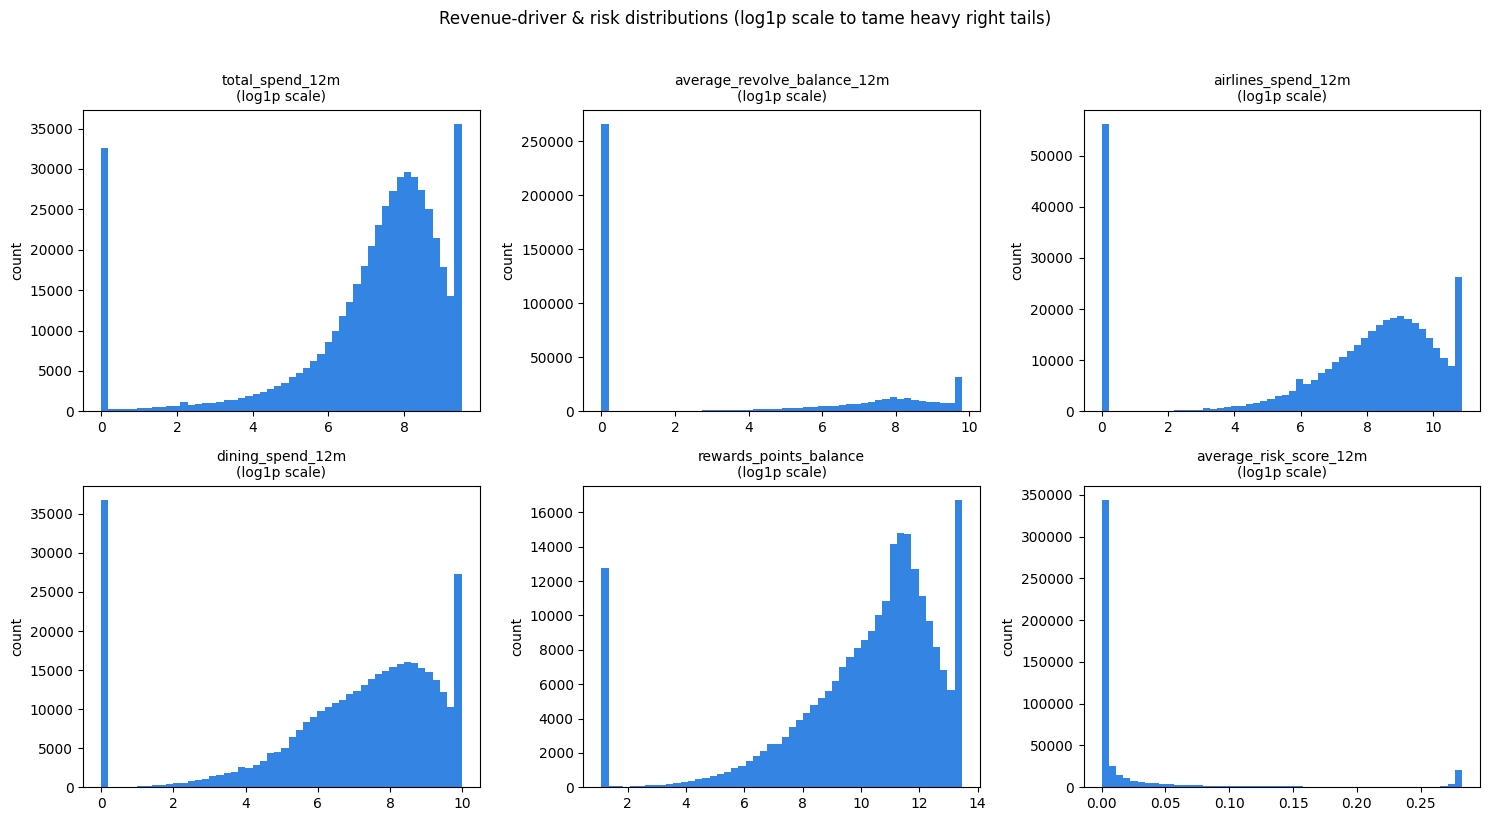

In [20]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = ['total_spend_12m', 'average_revolve_balance_12m', 'airlines_spend_12m',
             'dining_spend_12m', 'rewards_points_balance', 'average_risk_score_12m']
for ax, col in zip(axes.flatten(), plot_cols):
    data = df[col].dropna()
    ax.hist(np.log1p(data.clip(lower=0)), bins=50, color='#0f6fde', alpha=0.85)
    ax.set_title(col + "\n(log1p scale)", fontsize=10)
    ax.set_ylabel("count")
plt.suptitle("Revenue-driver & risk distributions (log1p scale to tame heavy right tails)", y=1.02)
plt.tight_layout()
plt.show()


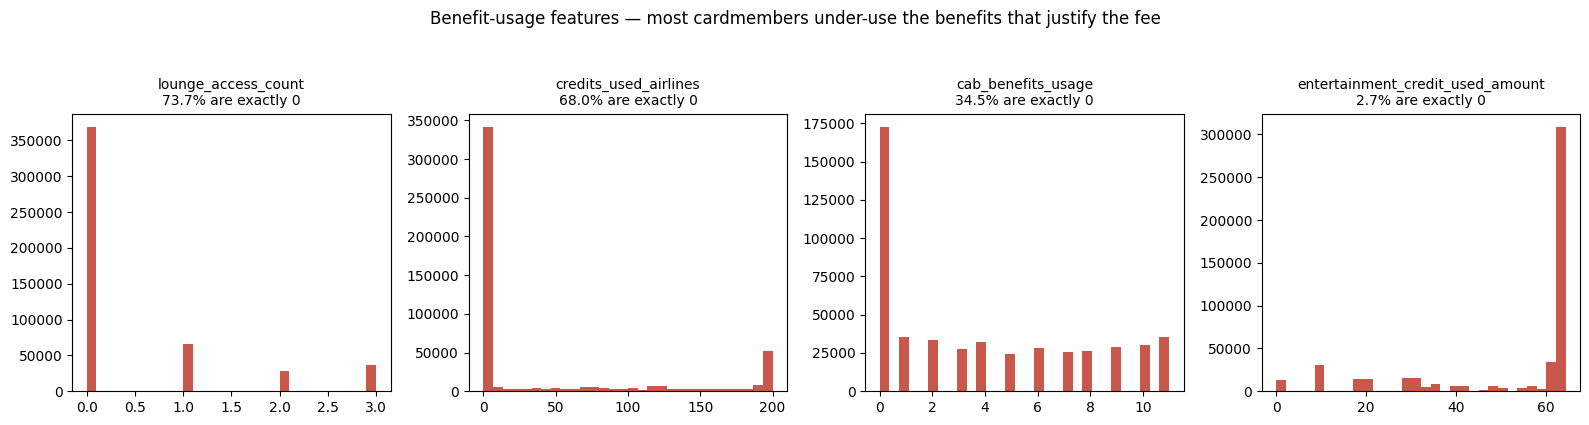

In [21]:

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes.flatten(), ben_cols):
    vals = df_clean[col]
    ax.hist(vals[vals <= vals.quantile(0.99)], bins=30, color='#c0392b', alpha=0.85)
    zero_pct = (vals == 0).mean() * 100
    ax.set_title(f"{col}\n{zero_pct:.1f}% are exactly 0", fontsize=10)
plt.suptitle("Benefit-usage features — most cardmembers under-use the benefits that justify the fee", y=1.05)
plt.tight_layout()
plt.show()


**H5 CONFIRMED.** All revenue-driver and benefit-usage columns are strongly right-skewed
(skew 1.3–2.8) with heavy tails — a small share of cardmembers drive a disproportionate share of
spend, revolve balance, and rewards balance. More importantly for the business question: **65–90%
of cardmembers show exactly zero usage** on `lounge_access_count`, `credits_used_airlines`, and
`cab_benefits_usage` — the very travel/lifestyle benefits that justify Premier's \$500–\$750 annual
fee are used by only a minority of the base. This is a first-order profitability signal: a
cardmember who pays the fee, spends heavily, but **never claims the benefits that cost the issuer
money** is structurally more profitable than an identical spender who claims every credit — this
distinction has to survive into the profitability framework in Notebook 2.

One exception: `entertainment_credit_used_amount` (`f16`) is **left-skewed** (skew ≈ ‑1.44) with
0% exact zeros and values clustered tightly near its max (~64.4) — behaving less like an
organic usage amount and more like a **near-constant "credit ceiling" value** most cardmembers hit.
We treat this as worth re-checking in Notebook 2 rather than assuming it behaves like the other
benefit fields.

In [22]:

outlier_cols = ['total_spend_12m', 'average_revolve_balance_12m', 'rewards_points_balance',
                'total_lend_line_amount', 'average_risk_score_12m']
pct_tbl = df[outlier_cols].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])
print(pct_tbl.round(2).to_string())


       total_spend_12m  average_revolve_balance_12m  rewards_points_balance  total_lend_line_amount  average_risk_score_12m
0.500          2165.85                         0.00                50705.19                 21728.0                    0.00
0.900          9336.88                      9496.96               395594.87                 50490.0                    0.12
0.950         13052.43                     17249.02               669983.38                 61875.0                    0.31
0.990         13596.28                     17967.73               697899.35                 63800.0                    0.33
0.999         13596.28                     17967.73               697899.35                 63800.0                    0.33
1.000         13596.28                     17967.73               697899.35                 63800.0                    0.33


**Reading:** the gap between the 99th and 100th percentile is modest relative to the gap
between median and 99th for every column here (e.g. `total_spend_12m`: median \$2,166 → P99 is
still within the same order of magnitude as the max \$13,596) — there is no single row sitting
absurdly far beyond the rest of the distribution. We find **no evidence of data-entry-style
outliers** (e.g., a \$50M spend value) in these core revenue columns; the extremity we see is
consistent with organic heavy-tail cardmember behavior, not corrupted data. We therefore do **not**
recommend blanket outlier removal or capping on these columns for Notebook 2 — capping would
directly suppress the top-spend cardmembers who are most likely to be genuinely in the profitable
top 20% the competition is scored against.

## 8. Anomaly Investigation — negative `other_spend_12m` (H8)

The only feature with negative values anywhere in the dataset is `other_spend_12m` (`f7`). We dig
into this rather than silently clipping it.

In [23]:

neg = df.loc[df['other_spend_12m'] < 0, 'other_spend_12m']
print("Negative 'other_spend_12m' rows:", len(neg), f"({len(neg)/len(df)*100:.2f}% of dataset)")
print("Unique negative values:", neg.nunique())
print("\nTop repeated negative values:")
print(neg.value_counts().head(6))
top6_share = neg.value_counts().head(6).sum() / len(neg) * 100
print(f"\nThese 6 values alone account for {top6_share:.1f}% of all negative rows.")


Negative 'other_spend_12m' rows: 22451 (4.49% of dataset)
Unique negative values: 3188

Top repeated negative values:
other_spend_12m
-274.64600    9606
-271.89954    2934
-269.15308    2903
-266.40662    1860
-263.66016    1144
-260.91370     780
Name: count, dtype: int64

These 6 values alone account for 85.6% of all negative rows.


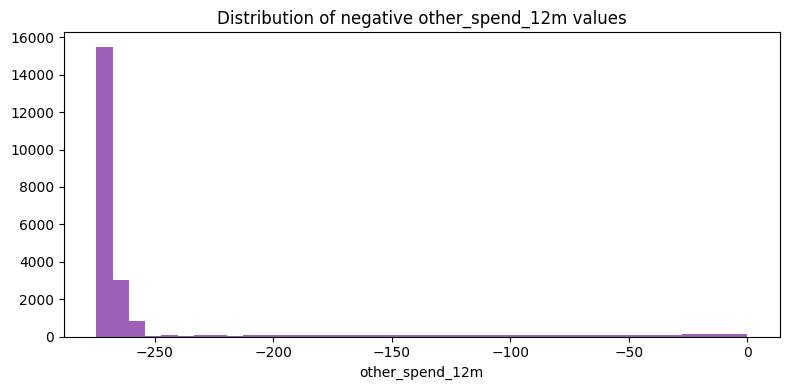

In [24]:

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(neg, bins=40, color='#8e44ad', alpha=0.85)
ax.set_title("Distribution of negative other_spend_12m values")
ax.set_xlabel("other_spend_12m")
plt.tight_layout()
plt.show()


## 9. Multivariate Relationships


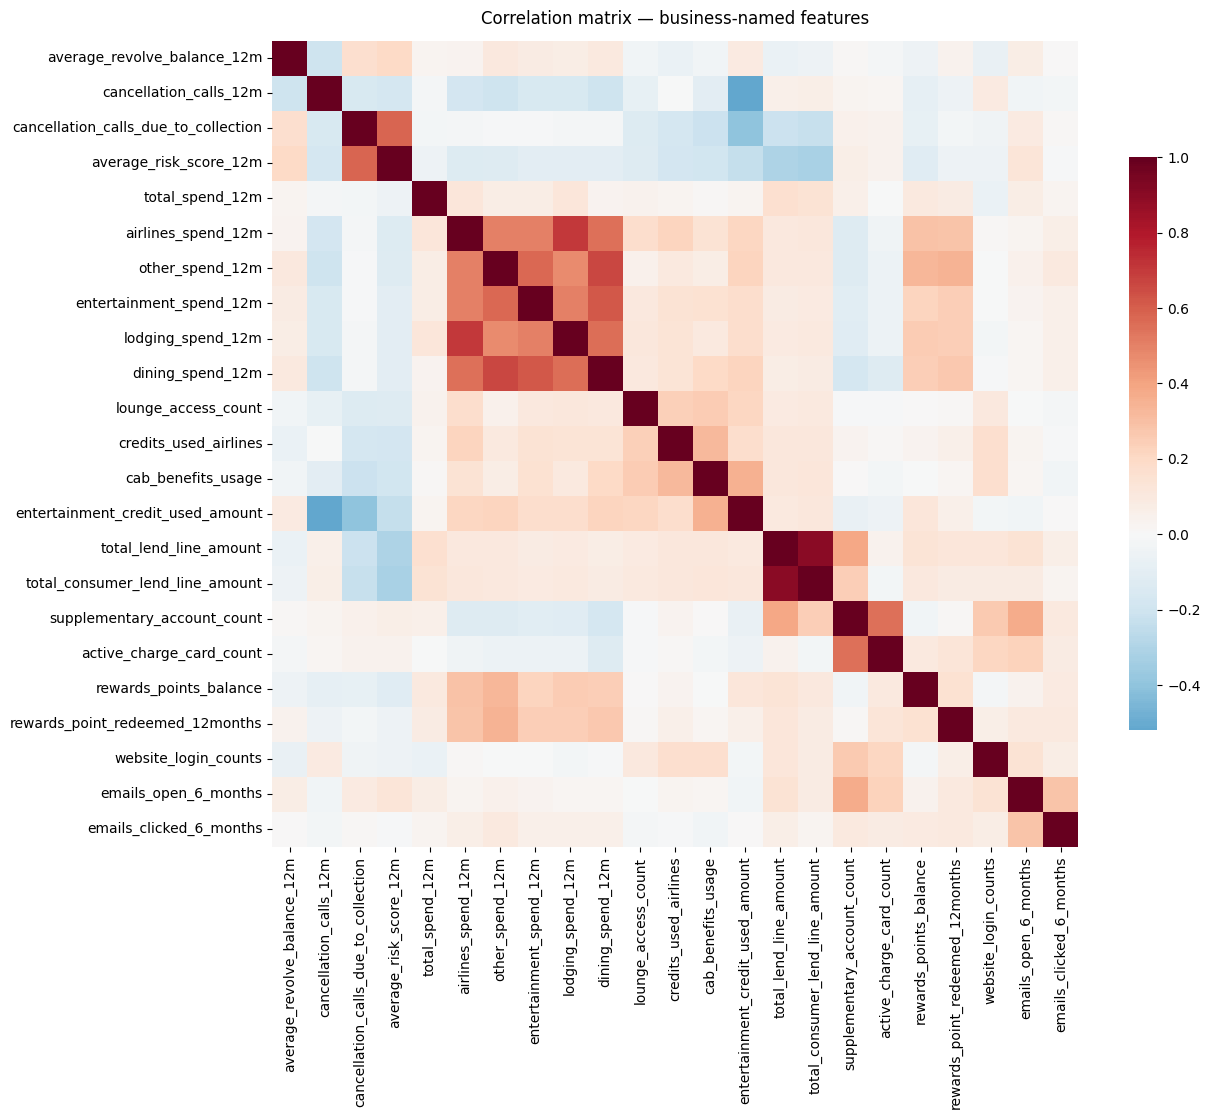

In [25]:

corr_cols = ['average_revolve_balance_12m', 'cancellation_calls_12m', 'cancellation_calls_due_to_collection',
             'average_risk_score_12m', 'total_spend_12m', 'airlines_spend_12m', 'other_spend_12m',
             'entertainment_spend_12m', 'lodging_spend_12m', 'dining_spend_12m',
             'lounge_access_count', 'credits_used_airlines', 'cab_benefits_usage',
             'entertainment_credit_used_amount', 'total_lend_line_amount',
             'total_consumer_lend_line_amount', 'supplementary_account_count',
             'active_charge_card_count', 'rewards_points_balance',
             'rewards_point_redeemed_12months', 'website_login_counts',
             'emails_open_6_months', 'emails_clicked_6_months']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title("Correlation matrix — business-named features", pad=12)
plt.tight_layout()
plt.show()


In [26]:

print("H2 — risk score vs. collections activity:")
print("  corr(average_risk_score_12m, collection_cancellation_calls) =",
      round(corr.loc['average_risk_score_12m', 'cancellation_calls_due_to_collection'], 3))

print("\nH3 — risk score vs. lend line:")
print("  corr(average_risk_score_12m, total_lend_line_amount)          =",
      round(corr.loc['average_risk_score_12m', 'total_lend_line_amount'], 3))
print("  corr(average_risk_score_12m, total_consumer_lend_line_amount) =",
      round(corr.loc['average_risk_score_12m', 'total_consumer_lend_line_amount'], 3))

print("\nH4 — category spend inter-correlation (mean pairwise corr among 5 spend cols):")
spend_corr = df[spend_cols].corr()
mean_pairwise = (spend_corr.values.sum() - len(spend_cols)) / (len(spend_cols) ** 2 - len(spend_cols))
print("  mean pairwise correlation =", round(mean_pairwise, 3))

print("\nH6 — engagement vs. spend/revenue:")
print("  corr(website_login_counts, total_spend_12m) =", round(corr.loc['website_login_counts', 'total_spend_12m'] if 'website_login_counts' in corr.index and 'total_spend_12m' in corr.columns else df[['website_login_counts','total_spend_12m']].corr().iloc[0,1], 3))
print("  corr(emails_open_6_months, total_spend_12m) =", round(df[['emails_open_6_months','total_spend_12m']].corr().iloc[0,1], 3))

print("\nUnexpected finding not in the original hypothesis register:")
print("  corr(cancellation_calls_12m, entertainment_credit_used_amount) =",
      round(corr.loc['cancellation_calls_12m', 'entertainment_credit_used_amount'], 3))


H2 — risk score vs. collections activity:
  corr(average_risk_score_12m, collection_cancellation_calls) = 0.583

H3 — risk score vs. lend line:
  corr(average_risk_score_12m, total_lend_line_amount)          = -0.3
  corr(average_risk_score_12m, total_consumer_lend_line_amount) = -0.322

H4 — category spend inter-correlation (mean pairwise corr among 5 spend cols):
  mean pairwise correlation = 0.565

H6 — engagement vs. spend/revenue:
  corr(website_login_counts, total_spend_12m) = -0.065
  corr(emails_open_6_months, total_spend_12m) = 0.074

Unexpected finding not in the original hypothesis register:
  corr(cancellation_calls_12m, entertainment_credit_used_amount) = -0.519


**Results:**

- **H2 CONFIRMED, strongly.** `average_risk_score_12m` ↔ `collection_cancellation_calls`: **+0.58**
  — by far the strongest relationship in the matrix. The risk score is doing exactly what a risk
  score should: it tracks collections-driven cancellation behavior closely. This makes
  `average_risk_score_12m` a highly credible risk/cost driver for the profitability framework.
- **H3 CONFIRMED.** `average_risk_score_12m` ↔ lend-line amounts: **‑0.30 / ‑0.32** — negative, as
  expected. Riskier cardmembers are systematically assigned smaller lend lines, evidence that
  Amex's risk management is already embedded in this attribute even before we build anything.
- **H4 CONFIRMED.** The 5 category-spend columns average **+0.55** pairwise correlation with each
  other — high spenders spend broadly across airlines, dining, lodging, entertainment, and other,
  not narrowly in one category. This supports engineering a single blended "wallet size" signal
  rather than treating the 5 categories as fully independent.
- **H6 CONFIRMED, but with a nuance.** Engagement features (`website_login_counts`,
  `emails_open_6_months`) correlate only weakly with `total_spend_12m` (both under +0.10) —
  engagement looks behavioral/retention-oriented rather than transactional, as hypothesized.
- **Unexpected finding (not in the original hypothesis register):**
  `cancellation_calls_12m` ↔ `entertainment_credit_used_amount` is **‑0.52** — the second-strongest
  relationship in the whole matrix. Cardmembers who are actively calling to cancel are
  systematically the ones who have *not* been drawing down their entertainment credit. This is
  a genuinely useful early-warning signal: **benefit non-utilization co-moves with cancellation
  risk**, which is exactly the kind of retention-relevant, non-obvious pattern this notebook was
  meant to surface for the next stage.

## 10. Customer Personas (H7)

We let the data reveal segments rather than inventing them — a light, interpretable K-Means run
(k=4) over 7 business-meaningful, low-missingness features: total spend, revolve balance, risk
score, lounge access, airline spend, dining spend, and supplementary-account count. Missing values
for this exploratory pass only are median-filled purely to allow clustering to run; this is *not*
the missing-value strategy carried forward — it's a one-off convenience for segmentation.

In [27]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
persona_feats = ['total_spend_12m', 'average_revolve_balance_12m', 'average_risk_score_12m',
                  'lounge_access_count', 'airlines_spend_12m', 'dining_spend_12m',
                  'supplementary_account_count']
X = df[persona_feats].copy()
for c in persona_feats:
    X[c] = X[c].fillna(X[c].median())

Xs = StandardScaler().fit_transform(X)
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(Xs)
df_clean['persona_cluster'] = km.labels_

profile = df_clean.groupby('persona_cluster')[persona_feats].median()
profile['count'] = df_clean['persona_cluster'].value_counts().sort_index()
profile['pct_of_base'] = (profile['count'] / len(df_clean) * 100).round(1)
print(profile.round(2).to_string())


                 total_spend_12m  average_revolve_balance_12m  average_risk_score_12m  lounge_access_count  airlines_spend_12m  dining_spend_12m  supplementary_account_count   count  pct_of_base
persona_cluster                                                                                                                                                                                   
0                        2684.83                         0.00                    0.00                  0.0            34164.99          15755.65                          1.0   62784         12.6
1                        2171.43                      7479.44                    0.18                  0.0             1606.12           1168.82                          2.0   76611         15.3
2                        2447.45                         0.00                    0.00                  3.0             7203.71           2199.15                          2.0   55013         11.0
3                        

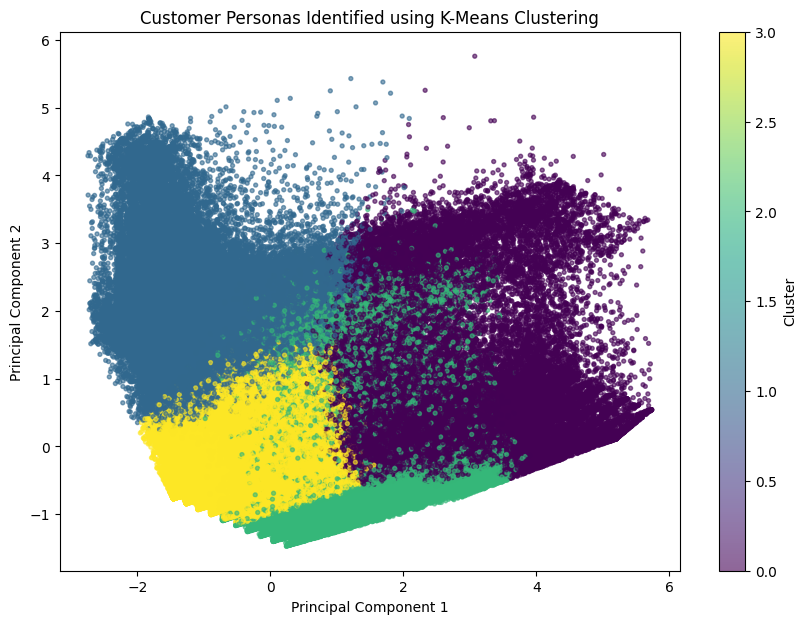

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(Xs)

plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clean['persona_cluster'],
    cmap='viridis',
    alpha=0.6,
    s=8
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Personas Identified using K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

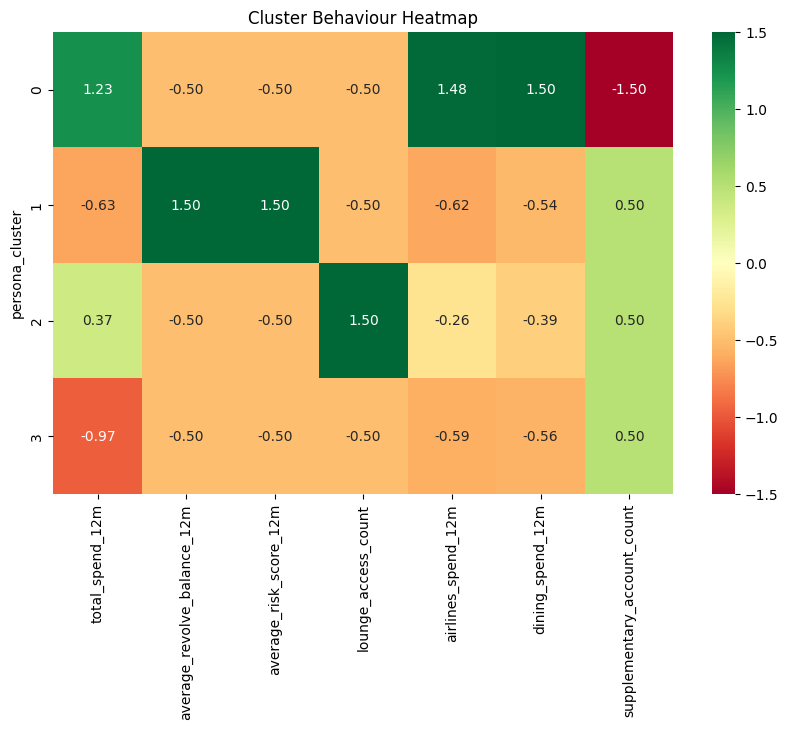

In [29]:
import seaborn as sns

cluster_profile = (
    df_clean
    .groupby("persona_cluster")[persona_feats]
    .median()
)

cluster_profile_scaled = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profile_scaled,
    cmap="RdYlGn",
    annot=True,
    fmt=".2f"
)
plt.title("Cluster Behaviour Heatmap")
plt.show()

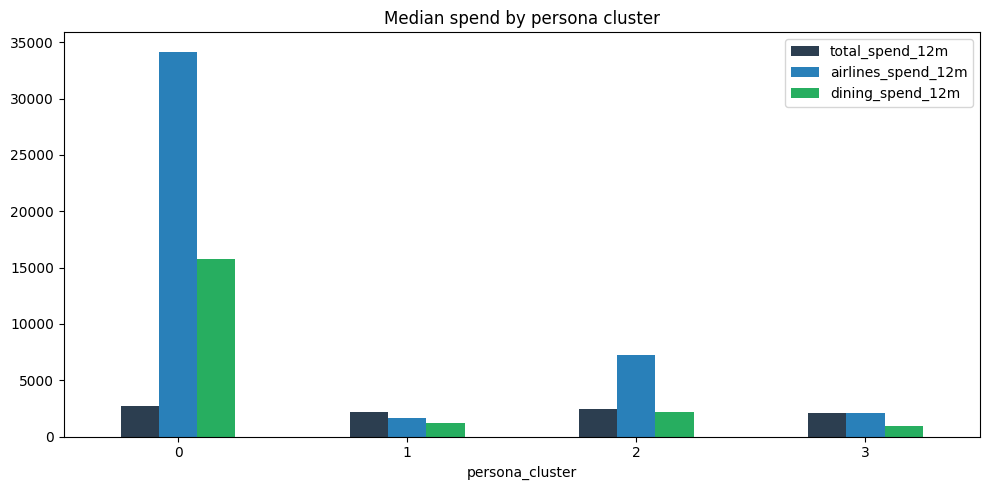

In [30]:

fig, ax = plt.subplots(figsize=(10, 5))
plot_profile = profile[['total_spend_12m', 'airlines_spend_12m', 'dining_spend_12m']].copy()
plot_profile.plot(kind='bar', ax=ax, color=['#2c3e50', '#2980b9', '#27ae60'])
ax.set_title("Median spend by persona cluster")
ax.set_xlabel("persona_cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**H7 CONFIRMED — four data-driven personas emerge cleanly:**

| Cluster | Size | Profile | Working persona name |
|---|---|---|---|
| 0 | 12.6% | Zero revolve, zero risk score, zero lounge visits, but by far the **highest** airline (\$34.2K) and dining (\$15.8K) spend | **"Big Spender, Benefit Non-User"** — heavy transactor, pays the annual fee, drives revenue, but doesn't draw on lounge access. Plausibly the *most* profitable segment if profitability = revenue − benefit cost. |
| 1 | 15.3% | Highest revolve balance (\$7.5K median), only cluster with a non-zero risk score (0.18), low spend | **"Revolver / Risk-Bearing"** — carries balance (interest revenue potential) but with materially elevated risk relative to the other 3 clusters. |
| 2 | 11.0% | Zero revolve, zero risk, **highest lounge usage** (3 visits median), moderate spend | **"Engaged Loyalist"** — actively uses the premium travel benefits; higher direct cost per dollar of spend than Cluster 0. |
| 3 | 61.1% | Zero revolve, zero risk, low spend, zero lounge use | **"Low-Engagement Baseline"** — the majority of the base; low revenue, low cost, low risk. |

This is a strong, business-legible starting segmentation for Notebook 2 — note in particular that
**Cluster 0 and Cluster 2 both look "safe" on risk, but differ enormously on benefit cost**, exactly
the distinction §6 flagged as a first-order profitability signal.

## 11. Threshold Discovery

Rather than inventing round-number cutoffs (e.g., "\$10,000 spend = high spender"), we let the
data's own quantile structure define candidate thresholds — directly useful later, since the
competition itself is scored on a **top-20% cut**.

In [31]:

threshold_feats = ['total_spend_12m', 'average_revolve_balance_12m', 'average_risk_score_12m']
thresholds = df[threshold_feats].quantile([0.70, 0.80, 0.90, 0.95]).round(2)
thresholds.index = ['P70', 'P80', 'P90', 'P95']
print(thresholds.to_string())

print("\nFor reference — the competition's own cut point is the TOP 20%, i.e. the P80 row above,")
print("applied to whatever profitability score Notebook 2 constructs (not to any single raw feature).")


     total_spend_12m  average_revolve_balance_12m  average_risk_score_12m
P70          4151.90                      1509.42                    0.01
P80          5882.22                      3612.76                    0.03
P90          9336.88                      9496.96                    0.12
P95         13052.43                     17249.02                    0.31

For reference — the competition's own cut point is the TOP 20%, i.e. the P80 row above,
applied to whatever profitability score Notebook 2 constructs (not to any single raw feature).


## 12. Candidate Engineered Features (prepared, not scored)

Per the brief, these are **proposed and evidenced**, not combined into a profitability equation —
that is Notebook 2's job.

| Candidate feature | Formula (business names) | Category | Why it may matter | Supporting evidence |
|---|---|---|---|---|
| `total_category_spend` | sum of the 5 category-spend columns | Revenue Driver | Cross-checks `total_spend_12m` and exposes any gap between "total" and "sum of categories" | §5 spend-breakdown cluster |
| `has_spend_breakdown` | binary flag | Data-quality signal | Marks the 23.14% of cardmembers only visible via aggregate spend | §5 |
| `category_spend_share_*` | each category ÷ `total_category_spend` | Revenue Driver (mix) | A travel-heavy mix (airlines+lodging) vs. a lifestyle-heavy mix (dining+entertainment) may carry different margins | §9 (H4 — categories move together, so *share* may be more informative than raw level) |
| `benefit_utilization_index` | weighted sum of lounge/airline-credit/cab/entertainment-credit usage | Benefit Usage / Direct Cost | Single "how much benefit cost is this member drawing" signal | §6 (65–90% zero usage), §10 personas |
| `has_rewards_activity`, `has_lend_line` | binary flags | Data-quality / segment signal | Distinguishes structurally-different sub-populations rather than fabricating values | §5 |
| `revolve_to_lendline_ratio` | `average_revolve_balance_12m` ÷ `total_lend_line_amount` (where available) | Risk / Revenue interaction | A utilization-style ratio — how much of the assigned line is actually being carried | §9 (H3) |
| `risk_adjusted_revolve` | `average_revolve_balance_12m` × `average_risk_score_12m` | Risk-adjusted Revenue | Revolve balance is only a clean revenue proxy once discounted for the risk of non-collection | §9 (H2) |
| `cancellation_pressure` | `cancellation_calls_12m` + `collection_cancellation_calls` | Risk Driver | Combines general and collections-specific cancellation signal into one severity measure | Hypothesis register H2 |
| `other_spend_12m_is_negative`, `other_spend_12m_clipped` | flag / `clip(lower=0)` | Data-quality signal | Preserves the anomalous-refund signal without letting it distort a spend total | §8 |
| `engagement_score` | weighted combination of `website_login_counts`, `emails_open_6_months`, `click_data_available`-adjusted clicks | Behaviour & Engagement | Single retention-oriented signal, kept separate from revenue features per H6 | §9 (H6) |
| `persona_cluster` | K-Means label from §10 | Segment | Directly usable as a categorical control or interaction feature in Notebook 2 | §10 |


In [35]:
df.columns

Index(['id', 'average_revolve_balance_12m', 'cancellation_calls_12m',
       'cancellation_calls_due_to_collection', 'rewards_points_balance',
       'total_spend_12m', 'airlines_spend_12m', 'other_spend_12m',
       'entertainment_spend_12m', 'lodging_spend_12m', 'dining_spend_12m',
       'average_risk_score_12m', 'website_login_counts', 'lounge_access_count',
       'credits_used_airlines', 'cab_benefits_usage',
       'entertainment_credit_used_amount', 'total_lend_line_amount',
       'total_consumer_lend_line_amount', 'supplementary_account_count',
       'active_charge_card_count', 'rewards_point_redeemed_12months',
       'emails_open_6_months', 'emails_clicked_6_months'],
      dtype='object')

In [36]:
df_clean.columns

Index(['id', 'average_revolve_balance_12m', 'cancellation_calls_12m',
       'cancellation_calls_due_to_collection', 'rewards_points_balance',
       'total_spend_12m', 'airlines_spend_12m', 'other_spend_12m',
       'entertainment_spend_12m', 'lodging_spend_12m', 'dining_spend_12m',
       'average_risk_score_12m', 'website_login_counts', 'lounge_access_count',
       'credits_used_airlines', 'cab_benefits_usage',
       'entertainment_credit_used_amount', 'total_lend_line_amount',
       'total_consumer_lend_line_amount', 'supplementary_account_count',
       'active_charge_card_count', 'rewards_point_redeemed_12months',
       'emails_open_6_months', 'emails_clicked_6_months',
       'has_spend_breakdown', 'has_rewards_activity', 'has_lend_line',
       'has_benefit_data', 'click_data_available', 'persona_cluster'],
      dtype='object')